In [1]:
import matplotlib as mpl 
import matplotlib.pyplot as plt 
import time 
import numpy as np

### PART 2.1. Download and convert image

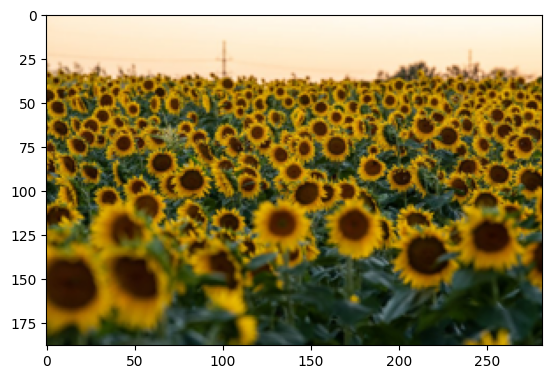

In [38]:
import os
import wget
from PIL import Image


def get_image(url, filename, ratio):
    jpg = f'{filename}.jpg'
    png = f'{filename}.png'
    if not os.path.exists(jpg):
        wget.download(url, jpg)

    img = Image.open(jpg)
    new_size = (int(img.width * ratio), int(img.height * ratio))
    img_resized = img.resize(new_size)
    img_resized.save(png, format="PNG")
    return plt.imread(png)


url = 'https://showme.missouri.edu/wp-content/uploads/2022/09/092722Sunflowers5-940x627.jpg'
img = get_image(url, 'sunflower', 0.3)
plt.imshow(img)

### PART 2.2. Define LoG function and show results

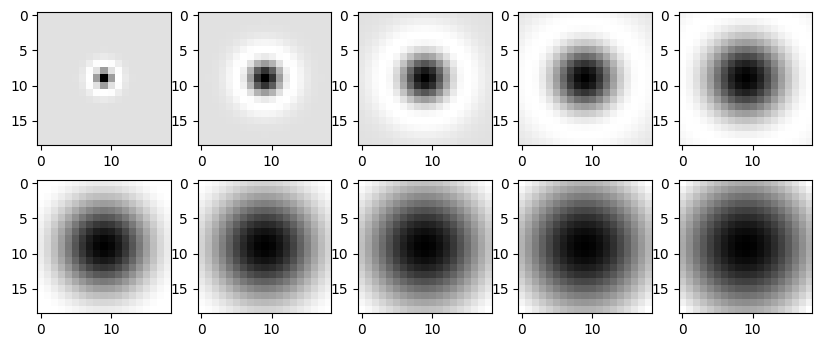

In [60]:
def LoG(sigma=1, size=19) -> np.array:
    '''
    Parameters:
        sigma: parameter of the Gaussian kernel and 
        size: overall image size of the filter (here by default 19x19 pixels)

    Returns:
        np.array: filter values (x, y)
    '''

    log_filter = np.zeros((size, size))
    center = size // 2
    for x in range(size):
        for y in range(size):
            X = x - center
            Y = y - center
            a = (X**2 + Y**2) / (2 * sigma**2)
            log_filter[x, y] = -1 / (np.pi * sigma**4) * (1 - a) * np.exp(-a)

    return log_filter


import matplotlib.gridspec as gridspec
figure = plt.figure(figsize=(10, 4))
gs = gridspec.GridSpec(2, 5, figure)

log_filters = []
for i in range(1, 11):
    log = LoG(sigma=i)
    ax = figure.add_subplot(gs[(i-1)//5, (i-1)%5])
    ax.imshow(log, cmap='grey')

### PART 2.3. Define filterImg and trackScale

In [113]:
def conv_2d(img, kernel, use_vectorized=True):

    k_height, k_width = kernel.shape
    pad_h = k_height // 2
    pad_w = k_width // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)

    if use_vectorized:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(padded, (k_height, k_width))
        # windows shape will be (H, W, kH, kW); perform elementwise multiplication and sum
        return np.einsum('ijkl,kl->ij', windows, kernel)

    output = np.zeros_like(img, dtype=np.float64)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            output[i, j] = np.sum(padded[i:i+k_height, j:j+k_width] * kernel)

    return output


def filterImg(img, fil):
    '''
    performs a convolution of img with fil

    Returns:
        same size of filtered image that 
    '''

    return conv_2d(img, fil)


def plot_images(imgs, columns=3, title=""):
    import matplotlib.gridspec as gridspec
    rows = (len(imgs) // columns) + 1
    figure = plt.figure(figsize=(columns * 4, rows * 4))
    gs = gridspec.GridSpec(rows, columns, figure)

    for i, img in enumerate(imgs):
        ax = figure.add_subplot(gs[i//columns, i%columns])
        ax.imshow(img, cmap='grey')
    
    plt.title(title)
    plt.tight_layout()
    plt.show()


def trackScale(img, sigmas, size, threshold):
    log_filters = [LoG(s, size) for s in sigmas]

    imgs = []
    for log_filter in log_filters:
        new_img = filterImg(img, log_filter)
        imgs.append(new_img)

    imgs = np.array(imgs)
    plot_images(imgs, columns=6, title="Filtered Images")

    # find maximum value of each pixels and sigma indice.
    filMaxScale = np.max(imgs, axis=0)
    scale_index = np.argmax(imgs, axis=0)

    figure = plt.figure(figsize=(10, 10))
    ax = figure.add_subplot(111)
    ax.imshow(img, cmap='gray')
    ax.set_title("LoG Scale Blob Detection")
    
    coords = np.argwhere(filMaxScale >= threshold)
    for (y, x) in coords:
        sigma_candidate = sigmas[ scale_index[y, x] ]
        radius = np.sqrt(3) * sigma_candidate
        circle = plt.Circle((x, y), radius, color='red', fill=False, linewidth=1.25)
        ax.add_patch(circle)

    ax.axis('off')
    plt.show()
    return filMaxScale

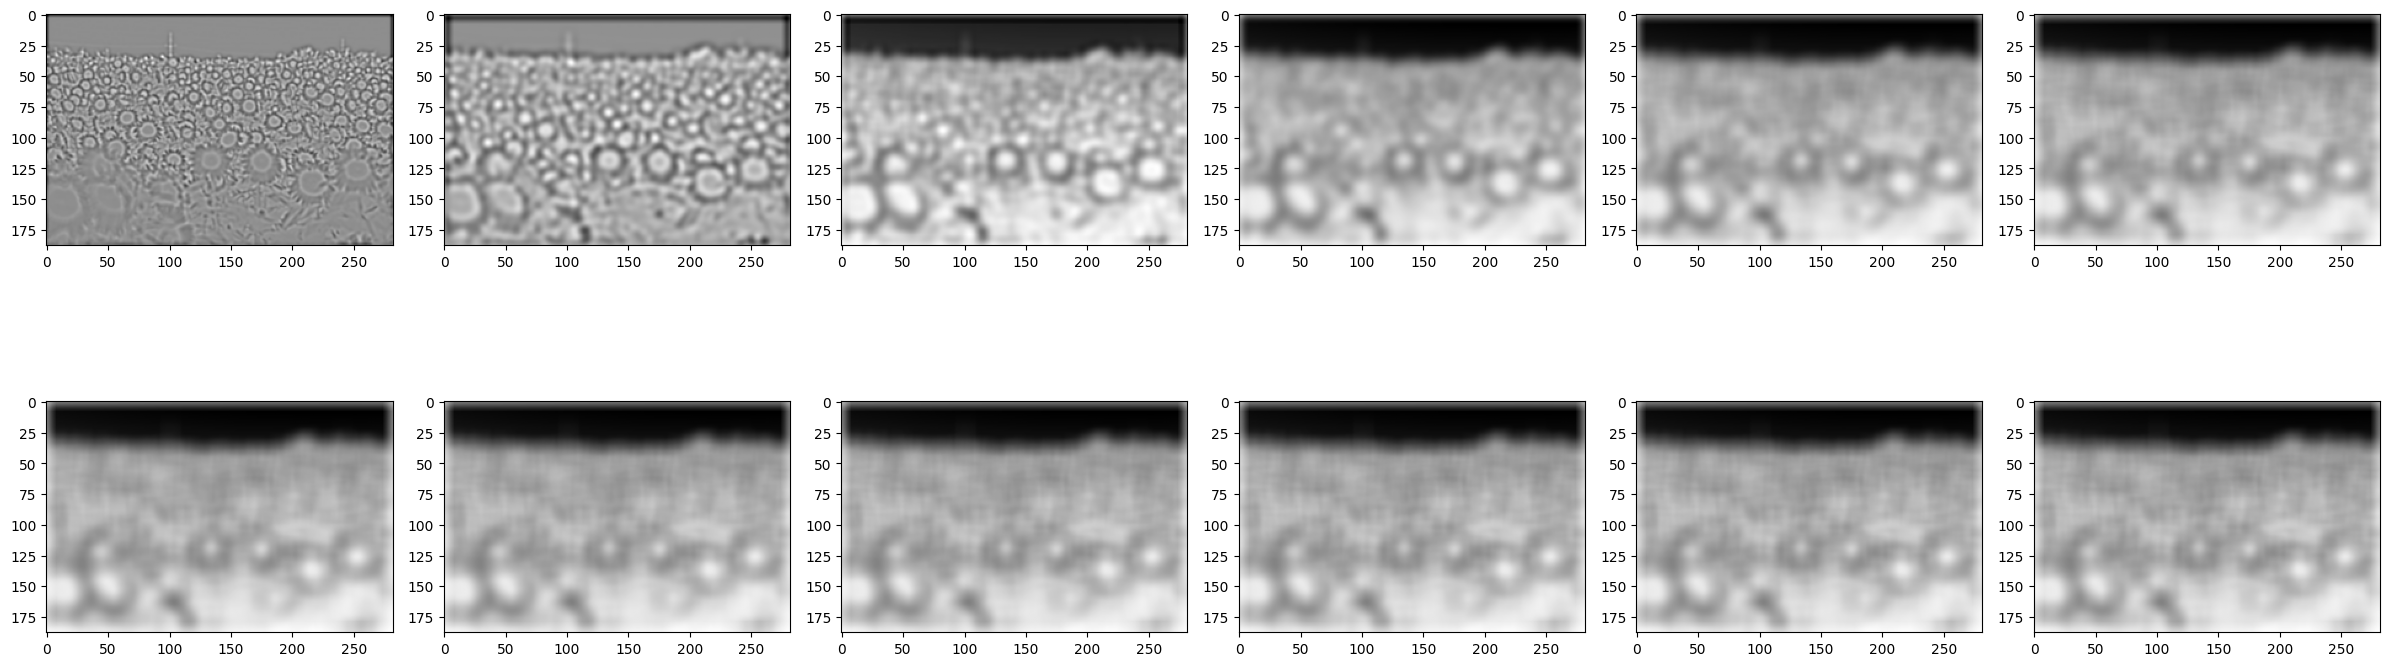

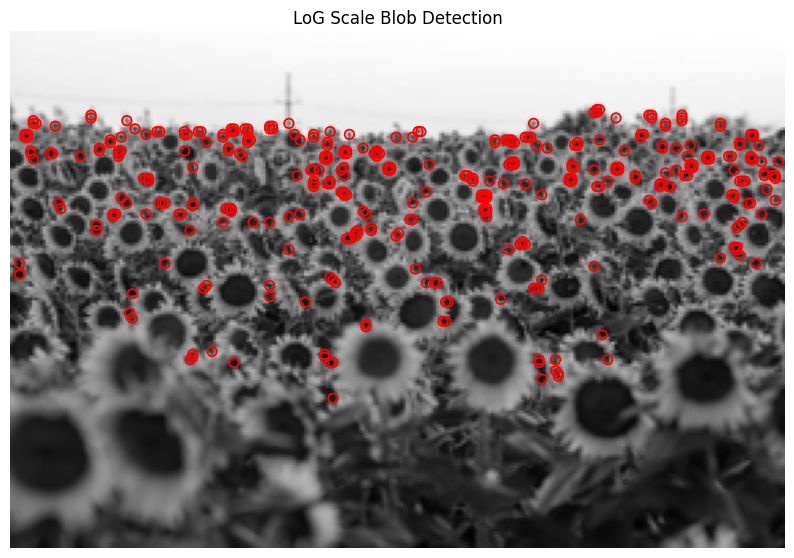

In [112]:

# Grayscale (ITU-R BT.601)
grayscale_img = img @ [0.2989, 0.5870, 0.1140]

sigmas = range(1, 25, 2)
result = trackScale(grayscale_img, sigmas, 17, 0.15)
